Jupyter Notebook for the Kaggle Competition (Machine Learning - CentraleSupélec - January 2025)  
PAES DE ALMEIDA NINA DUARTE, Pedro ; COLLIER, Grégoire ; PERARDT MAGALHÃES BRITO, Romero

Import necessary packages

In [109]:
import geopandas as gpd
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import numpy as np


from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score

Import data (as shown in the baseline code) and treat NaN

In [142]:
change_type_map = {'Demolition': 0, 'Road': 1, 'Residential': 2, 'Commercial': 3, 'Industrial': 4,
                   'Mega Projects': 5}

## Read csvs

train_df = gpd.read_file('train.geojson', index_col=0)
test_df = gpd.read_file('test.geojson', index_col=0)

train_y = train_df['change_type'].apply(lambda x: change_type_map[x])

submission_df = pd.DataFrame(test_df['index'])

c:\Users\pedro\AppData\Local\Programs\Python\Python311\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: driver GeoJSON does not support open option INDEX_COL
  return ogr_read(
c:\Users\pedro\AppData\Local\Programs\Python\Python311\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: driver GeoJSON does not support open option INDEX_COL
  return ogr_read(


In [111]:
features = train_df.columns.to_list()
features = [feature for feature in features if feature != 'change_type']

In [112]:
train_df.shape

(296146, 45)

Fill NaN with mean

In [145]:
ignore_columns = ['urban_type', 'geography_type', 'change_type','date0', 'change_status_date0', 'date1',
                   'change_status_date1','date2', 'change_status_date2','date3', 'change_status_date3', 
                   'date4', 'change_status_date4', 'index', 'geometry']

for col in train_df.columns:
    if col not in ignore_columns:
        train_df[col].fillna(train_df[col].mean(), inplace=True)

C:\Users\pedro\AppData\Local\Temp\ipykernel_28748\2416107534.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df[col].fillna(train_df[col].mean(), inplace=True)


Fill missing dates with closest date (one above)

In [146]:
train_df['date0'].fillna(method='ffill', inplace=True)
train_df['date1'].fillna(method='ffill', inplace=True)
train_df['date2'].fillna(method='ffill', inplace=True)
train_df['date3'].fillna(method='ffill', inplace=True)
train_df['date4'].fillna(method='ffill', inplace=True)

C:\Users\pedro\AppData\Local\Temp\ipykernel_28748\4175239564.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['date0'].fillna(method='ffill', inplace=True)
C:\Users\pedro\AppData\Local\Temp\ipykernel_28748\4175239564.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  train_df['date0'].fillna(method='ffill', inplace=True)
C:\Users\pedro\AppData\Local\Temp\ipykernel_28748\4175239564.py:2: FutureWarning: A value is trying to be s

In [147]:
train_df.isna().any()

urban_type              False
geography_type          False
change_type             False
img_red_mean_date1      False
img_green_mean_date1    False
img_blue_mean_date1     False
img_red_std_date1       False
img_green_std_date1     False
img_blue_std_date1      False
img_red_mean_date2      False
img_green_mean_date2    False
img_blue_mean_date2     False
img_red_std_date2       False
img_green_std_date2     False
img_blue_std_date2      False
img_red_mean_date3      False
img_green_mean_date3    False
img_blue_mean_date3     False
img_red_std_date3       False
img_green_std_date3     False
img_blue_std_date3      False
img_red_mean_date4      False
img_green_mean_date4    False
img_blue_mean_date4     False
img_red_std_date4       False
img_green_std_date4     False
img_blue_std_date4      False
img_red_mean_date5      False
img_green_mean_date5    False
img_blue_mean_date5     False
img_red_std_date5       False
img_green_std_date5     False
img_blue_std_date5      False
date0     

Treat 'N,A' in 'urban_type' and 'geography_type' column

In [148]:
## Used codes for urban_type and geography_type
train_df[train_df['urban_type'] == 'N,A']
train_df[train_df['geography_type'].str.contains('Snow')]['urban_type'].value_counts()
train_df['urban_type'].value_counts() 

urban_type
Dense Urban                           89427
Sparse Urban                          69189
Industrial                            60411
N,A                                   36682
Rural                                 20428
Sparse Urban,Industrial                8129
Dense Urban,Industrial                 7223
Sparse Urban,Urban Slum                1948
Urban Slum                             1472
Dense Urban,Urban Slum                  669
Rural,Industrial                        188
Urban Slum,Industrial                   181
Sparse Urban,Dense Urban                 74
Dense Urban,Rural                        52
Sparse Urban,Urban Slum,Industrial       47
Sparse Urban,Rural                       20
Urban Slum,Rural                          6
Name: count, dtype: int64

In [149]:
train_df.loc[((train_df['urban_type'] == 'N,A') & (train_df['geography_type'].str.contains("Dense Forest|Farms"))), 'urban_type'] = 'Rural'
train_df.loc[((train_df['urban_type'] == 'N,A') & (train_df['geography_type'].str.contains("Barren Land"))), 'urban_type'] = 'Urban'
train_df.loc[((train_df['urban_type'] == 'N,A') & (train_df['geography_type'].str.contains("Sparse Forest"))), 'urban_type'] = 'Sparse Urban'


## Costal had 3545 N,A, 136 Industrial, 32 Sparse Urban and 19 Dense Urban
train_df.loc[((train_df['urban_type'] == 'N,A') & (train_df['geography_type'].str.contains("Coastal"))), 'urban_type'] = 'Industrial'

## River had 664 Industrial, 215 Dense Urban and 115 N,A
train_df.loc[((train_df['urban_type'] == 'N,A') & (train_df['geography_type'].str.contains("River"))), 'urban_type'] = 'Industrial'

## Desert had 1520 N,A, 1350 Industrial, 1257 Sparse Urban and 940 Dense Urban
train_df.loc[((train_df['urban_type'] == 'N,A') & (train_df['geography_type'].str.contains("Desert"))), 'urban_type'] = 'Industrial'

## Lakes or Green Land had 15669 Sparse Urban and 237 N,A
train_df.loc[((train_df['urban_type'] == 'N,A') & (train_df['geography_type'].str.contains("Lakes|Green Land"))), 'urban_type'] = 'Sparse Urban'

## Grass Land had 41861 Dense Urban, 33048 Sparse Urban and 271 N,A
train_df.loc[((train_df['urban_type'] == 'N,A') & (train_df['geography_type'].str.contains("Grass Land"))), 'urban_type'] = 'Dense Urban'

## Snow had 4 Sparse Urban, 3 Dense Urban and 3 N,A
train_df.loc[((train_df['urban_type'] == 'N,A') & (train_df['geography_type'].str.contains("Snow"))), 'urban_type'] = 'Sparse Urban'

In [150]:
## Unideal substitution
train_df.loc[train_df['geography_type'] == 'N,A', 'geography_type'] = 'Sparse Forest'
train_df.loc[train_df['geography_type'] == None, 'geography_type'] = 'Sparse Urban'



In [151]:
train_df.shape

(296146, 45)

In [152]:
urban_types = list(train_df['urban_type'].unique())
unique_urban_types = []
for type in urban_types:
    #print(type, type.split(','))
    unique_urban_types += type.split(',')
unique_urban_types = set(unique_urban_types)
print(unique_urban_types)

geo_types = list(train_df['geography_type'].unique())
unique_geo_types = []
for type in geo_types:
    #print(type, type.split(','))
    unique_geo_types += type.split(',')
unique_geo_types = set(unique_geo_types)
print(unique_geo_types)

{'Urban Slum', 'Rural', 'Dense Urban', 'Industrial', 'Urban', 'Sparse Urban'}
{'Hills', 'Dense Forest', 'Grass Land', 'Farms', 'Sparse Forest', 'Barren Land', 'Snow', 'Lakes', 'River', 'Coastal', 'Desert'}


In [153]:
train_df.drop('index', axis = 1, inplace=True)


In [154]:
train_df['urban_type'] = train_df['urban_type'].apply(lambda x: x.split(','))
train_df['geography_type'] = train_df['geography_type'].apply(lambda x: x.split(','))

In [155]:
for unique_geo_type in unique_geo_types:
    train_df[unique_geo_type] = train_df['geography_type'].apply(lambda x: 1 if unique_geo_type in x else 0)
for unique_urban_type in unique_urban_types:
    train_df[unique_urban_type] = train_df['urban_type'].apply(lambda x: 1 if unique_urban_type in x else 0)

In [156]:
for column in train_df.columns:
    print(column)

urban_type
geography_type
change_type
img_red_mean_date1
img_green_mean_date1
img_blue_mean_date1
img_red_std_date1
img_green_std_date1
img_blue_std_date1
img_red_mean_date2
img_green_mean_date2
img_blue_mean_date2
img_red_std_date2
img_green_std_date2
img_blue_std_date2
img_red_mean_date3
img_green_mean_date3
img_blue_mean_date3
img_red_std_date3
img_green_std_date3
img_blue_std_date3
img_red_mean_date4
img_green_mean_date4
img_blue_mean_date4
img_red_std_date4
img_green_std_date4
img_blue_std_date4
img_red_mean_date5
img_green_mean_date5
img_blue_mean_date5
img_red_std_date5
img_green_std_date5
img_blue_std_date5
date0
change_status_date0
date1
change_status_date1
date2
change_status_date2
date3
change_status_date3
date4
change_status_date4
geometry
Hills
Dense Forest
Grass Land
Farms
Sparse Forest
Barren Land
Snow
Lakes
River
Coastal
Desert
Urban Slum
Rural
Dense Urban
Industrial
Urban
Sparse Urban


In [157]:

status = []
for column in ['change_status_date0', 'change_status_date1', 'change_status_date2', 'change_status_date3', 'change_status_date4']:
    status += list(train_df[column].unique())
status = set(status)
for element in status:
    print(element)

change_status_map = {'Materials Dumped': 2, 'Construction Done': 7, 'Construction Midway':6, 'Construction Started': 5, 'Greenland': 0, 'Prior Construction': 9,
                   'Land Cleared': 1,'Materials Introduced':4, 'Excavation': 3,'Operational': 8, None: 4.5}

train_df['change_status_date0'] = train_df['change_status_date0'].apply(lambda x: change_status_map[x])
train_df['change_status_date1'] = train_df['change_status_date1'].apply(lambda x: change_status_map[x])
train_df['change_status_date2'] = train_df['change_status_date2'].apply(lambda x: change_status_map[x])
train_df['change_status_date3'] = train_df['change_status_date3'].apply(lambda x: change_status_map[x])
train_df['change_status_date4'] = train_df['change_status_date4'].apply(lambda x: change_status_map[x])

Materials Introduced
Prior Construction
Greenland
None
Construction Midway
Land Cleared
Materials Dumped
Construction Started
Construction Done
Excavation
Operational


In [158]:
train_df['area'] = train_df['geometry'].area
train_df['length'] = train_df['geometry'].length

C:\Users\pedro\AppData\Local\Temp\ipykernel_28748\546592296.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  train_df['area'] = train_df['geometry'].area
C:\Users\pedro\AppData\Local\Temp\ipykernel_28748\546592296.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'length' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  train_df['length'] = train_df['geometry'].length


In [159]:
train_df.drop('geometry', axis = 1, inplace=True)

In [160]:
train_df.columns

Index(['urban_type', 'geography_type', 'change_type', 'img_red_mean_date1',
       'img_green_mean_date1', 'img_blue_mean_date1', 'img_red_std_date1',
       'img_green_std_date1', 'img_blue_std_date1', 'img_red_mean_date2',
       'img_green_mean_date2', 'img_blue_mean_date2', 'img_red_std_date2',
       'img_green_std_date2', 'img_blue_std_date2', 'img_red_mean_date3',
       'img_green_mean_date3', 'img_blue_mean_date3', 'img_red_std_date3',
       'img_green_std_date3', 'img_blue_std_date3', 'img_red_mean_date4',
       'img_green_mean_date4', 'img_blue_mean_date4', 'img_red_std_date4',
       'img_green_std_date4', 'img_blue_std_date4', 'img_red_mean_date5',
       'img_green_mean_date5', 'img_blue_mean_date5', 'img_red_std_date5',
       'img_green_std_date5', 'img_blue_std_date5', 'date0',
       'change_status_date0', 'date1', 'change_status_date1', 'date2',
       'change_status_date2', 'date3', 'change_status_date3', 'date4',
       'change_status_date4', 'Hills', 'Dense Fore

In [161]:
from datetime import datetime
date_format = "%d-%m-%Y"

#a = datetime.strptime('18-8-2008', date_format)
#b = datetime.strptime('22-12-2008', date_format)

for column in ['date0', 'date1', 'date2', 'date3', 'date4']:
    train_df[column] = train_df[column].apply(lambda x: datetime.strptime(x,date_format))

#delta = b - a

#print(delta.days) 

In [162]:
time_diffs = ['time_diff_1','time_diff_2','time_diff_3']
dates = ['date0', 'date1', 'date2', 'date3', 'date4']
for i in range(3):
    train_df[time_diffs[i]] = train_df[dates[i+1]] - train_df[dates[i]]
    train_df[time_diffs[i]] = train_df[time_diffs[i]].apply(lambda x: x.days)

In [163]:
#train_df.drop(['urban_type', 'geography_type'], axis = 1, inplace=True)
train_df.columns

Index(['urban_type', 'geography_type', 'change_type', 'img_red_mean_date1',
       'img_green_mean_date1', 'img_blue_mean_date1', 'img_red_std_date1',
       'img_green_std_date1', 'img_blue_std_date1', 'img_red_mean_date2',
       'img_green_mean_date2', 'img_blue_mean_date2', 'img_red_std_date2',
       'img_green_std_date2', 'img_blue_std_date2', 'img_red_mean_date3',
       'img_green_mean_date3', 'img_blue_mean_date3', 'img_red_std_date3',
       'img_green_std_date3', 'img_blue_std_date3', 'img_red_mean_date4',
       'img_green_mean_date4', 'img_blue_mean_date4', 'img_red_std_date4',
       'img_green_std_date4', 'img_blue_std_date4', 'img_red_mean_date5',
       'img_green_mean_date5', 'img_blue_mean_date5', 'img_red_std_date5',
       'img_green_std_date5', 'img_blue_std_date5', 'date0',
       'change_status_date0', 'date1', 'change_status_date1', 'date2',
       'change_status_date2', 'date3', 'change_status_date3', 'date4',
       'change_status_date4', 'Hills', 'Dense Fore

In [164]:
train_df.drop(time_diffs, axis=1, inplace = True)

In [165]:
preprocessed_df = train_df.drop(['urban_type', 'geography_type', 'change_type', 'date0', 'date1', 'date2', 'date3', 'date4'], axis=1)
train_y

0         1
1         1
2         1
3         1
4         0
         ..
296141    3
296142    2
296143    2
296144    2
296145    2
Name: change_type, Length: 296146, dtype: int64

In [166]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score

X_train, X_test, y_train, y_test = train_test_split(preprocessed_df, train_y, train_size=0.3, random_state = 0)

from sklearn.tree import DecisionTreeClassifier
dtree_model = DecisionTreeClassifier(max_depth = 30).fit(X_train, y_train)
dtree_predictions = dtree_model.predict(X_test)

# creating a confusion matrix
cm = confusion_matrix(y_test, dtree_predictions)

score = f1_score(y_test, dtree_predictions, average = 'macro')
cm

array([[13712,   347,  4705,  3235,    50,    10],
       [  289,  4120,  2180,  3454,    68,     9],
       [ 4584,  2035, 69155, 27693,   403,    34],
       [ 3118,  3633, 27343, 35484,   573,    55],
       [   52,    46,   299,   465,    45,     0],
       [    8,    10,    40,    49,     0,     0]], dtype=int64)

In [167]:
score

0.3744058667619246

Replicate steps above for test set

In [168]:
def pipeline(train_df):
    for col in train_df.columns:
        if col not in ignore_columns:
            train_df[col].fillna(train_df[col].mean(), inplace=True)

    train_df['date0'].fillna(method='ffill', inplace=True)
    train_df['date1'].fillna(method='ffill', inplace=True)
    train_df['date2'].fillna(method='ffill', inplace=True)
    train_df['date3'].fillna(method='ffill', inplace=True)
    train_df['date4'].fillna(method='ffill', inplace=True)

    train_df.loc[((train_df['urban_type'] == 'N,A') & (train_df['geography_type'].str.contains("Dense Forest|Farms"))), 'urban_type'] = 'Rural'
    train_df.loc[((train_df['urban_type'] == 'N,A') & (train_df['geography_type'].str.contains("Barren Land"))), 'urban_type'] = 'Urban'
    train_df.loc[((train_df['urban_type'] == 'N,A') & (train_df['geography_type'].str.contains("Sparse Forest"))), 'urban_type'] = 'Sparse Urban'


    ## Costal had 3545 N,A, 136 Industrial, 32 Sparse Urban and 19 Dense Urban
    train_df.loc[((train_df['urban_type'] == 'N,A') & (train_df['geography_type'].str.contains("Coastal"))), 'urban_type'] = 'Industrial'

    ## River had 664 Industrial, 215 Dense Urban and 115 N,A
    train_df.loc[((train_df['urban_type'] == 'N,A') & (train_df['geography_type'].str.contains("River"))), 'urban_type'] = 'Industrial'

    ## Desert had 1520 N,A, 1350 Industrial, 1257 Sparse Urban and 940 Dense Urban
    train_df.loc[((train_df['urban_type'] == 'N,A') & (train_df['geography_type'].str.contains("Desert"))), 'urban_type'] = 'Industrial'

    ## Lakes or Green Land had 15669 Sparse Urban and 237 N,A
    train_df.loc[((train_df['urban_type'] == 'N,A') & (train_df['geography_type'].str.contains("Lakes|Green Land"))), 'urban_type'] = 'Sparse Urban'

    ## Grass Land had 41861 Dense Urban, 33048 Sparse Urban and 271 N,A
    train_df.loc[((train_df['urban_type'] == 'N,A') & (train_df['geography_type'].str.contains("Grass Land"))), 'urban_type'] = 'Dense Urban'

    ## Snow had 4 Sparse Urban, 3 Dense Urban and 3 N,A
    train_df.loc[((train_df['urban_type'] == 'N,A') & (train_df['geography_type'].str.contains("Snow"))), 'urban_type'] = 'Sparse Urban'

    ## Unideal substitution
    train_df.loc[train_df['geography_type'] == 'N,A', 'geography_type'] = 'Sparse Forest'
    train_df.loc[train_df['geography_type'] == None, 'geography_type'] = 'Sparse Urban'

    train_df.drop('index', axis = 1, inplace=True)

    train_df['urban_type'] = train_df['urban_type'].apply(lambda x: x.split(','))
    train_df['geography_type'] = train_df['geography_type'].apply(lambda x: x.split(','))

    for unique_geo_type in unique_geo_types:
        train_df[unique_geo_type] = train_df['geography_type'].apply(lambda x: 1 if unique_geo_type in x else 0)
    for unique_urban_type in unique_urban_types:
        train_df[unique_urban_type] = train_df['urban_type'].apply(lambda x: 1 if unique_urban_type in x else 0)

    status = []
    for column in ['change_status_date0', 'change_status_date1', 'change_status_date2', 'change_status_date3', 'change_status_date4']:
        status += list(train_df[column].unique())
    status = set(status)
    for element in status:
        print(element)

    change_status_map = {'Materials Dumped': 2, 'Construction Done': 7, 'Construction Midway':6, 'Construction Started': 5, 'Greenland': 0, 'Prior Construction': 9,
                    'Land Cleared': 1,'Materials Introduced':4, 'Excavation': 3,'Operational': 8, None: 4.5}

    train_df['change_status_date0'] = train_df['change_status_date0'].apply(lambda x: change_status_map[x])
    train_df['change_status_date1'] = train_df['change_status_date1'].apply(lambda x: change_status_map[x])
    train_df['change_status_date2'] = train_df['change_status_date2'].apply(lambda x: change_status_map[x])
    train_df['change_status_date3'] = train_df['change_status_date3'].apply(lambda x: change_status_map[x])
    train_df['change_status_date4'] = train_df['change_status_date4'].apply(lambda x: change_status_map[x])

    train_df['area'] = train_df['geometry'].area
    train_df['length'] = train_df['geometry'].length

    train_df.drop('geometry', axis = 1, inplace=True)

    from datetime import datetime
    date_format = "%d-%m-%Y"

    #a = datetime.strptime('18-8-2008', date_format)
    #b = datetime.strptime('22-12-2008', date_format)

    for column in ['date0', 'date1', 'date2', 'date3', 'date4']:
        train_df[column] = train_df[column].apply(lambda x: datetime.strptime(x,date_format))

    #delta = b - a

    #print(delta.days) 

    time_diffs = ['time_diff_1','time_diff_2','time_diff_3']
    dates = ['date0', 'date1', 'date2', 'date3', 'date4']
    for i in range(3):
        train_df[time_diffs[i]] = train_df[dates[i+1]] - train_df[dates[i]]
        train_df[time_diffs[i]] = train_df[time_diffs[i]].apply(lambda x: x.days)

    train_df.drop(time_diffs, axis=1, inplace = True)

    preprocessed_df = train_df.drop(['date0', 'date1', 'date2', 'date3', 'date4'], axis=1)

    return preprocessed_df

preprocessed_test_df = pipeline(test_df)
preprocessed_test_df

C:\Users\pedro\AppData\Local\Temp\ipykernel_28748\848175427.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df[col].fillna(train_df[col].mean(), inplace=True)
C:\Users\pedro\AppData\Local\Temp\ipykernel_28748\848175427.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

F

Materials Introduced
Prior Construction
Greenland
None
Construction Midway
Land Cleared
Materials Dumped
Construction Started
Construction Done
Excavation
Operational


C:\Users\pedro\AppData\Local\Temp\ipykernel_28748\848175427.py:65: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  train_df['area'] = train_df['geometry'].area
C:\Users\pedro\AppData\Local\Temp\ipykernel_28748\848175427.py:66: UserWarning: Geometry is in a geographic CRS. Results from 'length' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  train_df['length'] = train_df['geometry'].length


,urban_type,geography_type,img_red_mean_date1,img_green_mean_date1,img_blue_mean_date1,img_red_std_date1,img_green_std_date1,img_blue_std_date1,img_red_mean_date2,img_green_mean_date2,...,Coastal,Desert,Urban Slum,Rural,Dense Urban,Industrial,Urban,Sparse Urban,area,length
0,[Urban],[Barren Land],203.333944,169.801486,152.200651,15.566236,16.008455,17.248278,187.051282,158.300672,...,0,0,0,0,0,0,1,0,1.017644e-07,0.001293
1,[Rural],[Desert],172.061525,147.685474,133.694478,41.475540,44.100325,45.832053,155.780912,135.136855,...,0,1,0,1,0,0,0,0,3.359779e-08,0.000735
2,[Rural],[Desert],159.368826,142.102024,127.979757,25.094292,22.485283,23.314198,160.848178,145.442915,...,0,1,0,1,0,0,0,0,2.582968e-08,0.000649
3,[Industrial],[Desert],200.918653,176.145032,160.827045,17.500086,19.342180,20.587617,175.678701,169.652776,...,0,1,0,0,0,1,0,0,4.355159e-07,0.002690
4,[Dense Urban],"[Barren Land, Sparse Forest]",166.621344,154.779757,149.726308,68.843646,72.361309,71.799610,149.589170,143.869542,...,0,0,0,0,1,0,0,0,9.817937e-08,0.001898
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120521,[Sparse Urban],"[Sparse Forest, Grass Land, Lakes]",74.594406,72.981199,62.822552,24.472312,19.897044,19.887582,89.628466,85.693444,...,0,0,0,0,0,0,0,1,3.984273e-07,0.003063
120522,[Sparse Urban],"[Sparse Forest, Grass Land, Lakes]",58.439701,62.549749,55.780079,21.440513,17.952821,17.289851,78.664141,73.863068,...,0,0,0,0,0,0,0,1,3.472850e-07,0.002739
120523,[Sparse Urban],"[Sparse Forest, Grass Land, Lakes]",42.641541,50.166332,49.730848,10.641932,9.309863,6.805194,52.940873,60.286320,...,0,0,0,0,0,0,0,1,3.052487e-07,0.002492
120524,[Sparse Urban],"[Coastal, Dense Forest, Grass Land]",47.581117,55.697246,49.512326,10.637095,9.854314,7.726375,64.082919,68.935690,...,1,0,0,0,0,0,0,1,2.733826e-07,0.002335


In [169]:
preprocessed_test_df = preprocessed_test_df.drop(['urban_type', 'geography_type'], axis=1)

In [170]:
dtree_predictions_kaggle = dtree_model.predict(preprocessed_test_df)
dtree_predictions_kaggle

array([2, 2, 2, ..., 2, 2, 2], dtype=int64)

In [171]:
submission_df.shape

(120526, 1)

In [172]:
submission_df['change_type'] = dtree_predictions_kaggle
submission_df

,index,change_type
0,0,2
1,1,2
2,2,2
3,3,5
4,4,2
...,...,...
120521,120521,1
120522,120522,3
120523,120523,2
120524,120524,2


In [178]:
submission_df = submission_df.rename(columns={'index': 'Id', 'change_type': 'change_type'})
submission_df

,Id,change_type
0,0,2
1,1,2
2,2,2
3,3,5
4,4,2
...,...,...
120521,120521,1
120522,120522,3
120523,120523,2
120524,120524,2


Create csv for submission

In [179]:
from pathlib import Path  
filepath = Path('./submission.csv')  
filepath.parent.mkdir(parents=True, exist_ok=True)  
submission_df.to_csv(filepath, columns=['Id', 'change_type'], index=False) 

New model w/ OneVsRest + SVC

In [182]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import LinearSVC

X_train, X_test, y_train, y_test = train_test_split(preprocessed_df, train_y, train_size=0.3, random_state = 0)

model = OneVsRestClassifier(LinearSVC(random_state=0)).fit(X_train, y_train)
predictions = model.predict(X_test)

# creating a confusion matrix
cm = confusion_matrix(y_test, predictions)

score = f1_score(y_test, predictions, average = 'macro')
cm

array([[ 2208,     0, 14987,  4864,     0,     0],
       [   35,     0,  6725,  3360,     0,     0],
       [  746,     0, 85434, 17724,     0,     0],
       [  598,     0, 39430, 30178,     0,     0],
       [    5,     0,   513,   389,     0,     0],
       [    1,     0,    67,    39,     0,     0]], dtype=int64)

In [183]:
score

0.22148008794409424

PyTorch Model

In [184]:
import torch
from torch import nn
from torch.utils.data import DataLoader

In [188]:
X_data = preprocessed_df.to_numpy()
y_data = train_y.to_numpy()
X_final_test = preprocessed_test_df.to_numpy()

X_data = torch.from_numpy(X_data).type(torch.float)
y_data = torch.from_numpy(y_data).type(torch.float)
X_final_test = torch.from_numpy(X_final_test).type(torch.float)

In [189]:
X_train_pt, X_test_pt, y_train_pt, y_test_pt = train_test_split(X_data, y_data, test_size=0.30, random_state=101)

In [225]:
model_pt = nn.Sequential(
    nn.Linear(in_features=X_train_pt.shape[1], out_features=128),
    nn.ReLU(),
    nn.Linear(in_features=128, out_features=512),
    nn.ReLU(),
    nn.Linear(in_features=512, out_features=256),
    nn.ReLU(),
    #nn.Linear(in_features=256, out_features=512),
    #nn.ReLU(),
    #nn.Linear(in_features=512, out_features=1024),
    #nn.ReLU(),
    nn.Linear(in_features=256, out_features=256),
    nn.ReLU(),
    nn.Linear(in_features=256, out_features=6)
    )

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_pt.parameters(),
                            lr = 0.0001)

In [194]:
from torcheval.metrics.functional import multiclass_f1_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

In [220]:
y_train_pt = y_train_pt.type(torch.LongTensor)
y_test_pt = y_test_pt.type(torch.LongTensor)

In [226]:
epochs = 100
train_loss = []
test_loss = []
epoch_count = []

for epoch in range(epochs):
    epoch_count.append(epoch)

    ### Train model

    model_pt.train()

    #y_pred_train = torch.round(torch.sigmoid(model_pt(X_train_pt)))
    y_pred_train = model_pt(X_train_pt)

    loss = loss_fn(y_pred_train, y_train_pt)

    train_loss.append(loss)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    ### Evalualte model

    model_pt.eval()

    with torch.inference_mode():
        y_pred_test = model_pt(X_test_pt)

    loss_test = loss_fn(y_pred_test, y_test_pt)
    test_loss.append(loss_test)

    if epoch % 10 == 0:
        print(f"Epoch {epoch} ||| train loss {loss} ||| test loss {loss_test}")

Epoch 0 ||| train loss 1.9812383651733398 ||| test loss 1.6100690364837646
Epoch 10 ||| train loss 1.1541743278503418 ||| test loss 1.1396870613098145
Epoch 20 ||| train loss 1.124060034751892 ||| test loss 1.122575044631958
Epoch 30 ||| train loss 1.1130995750427246 ||| test loss 1.1126943826675415
Epoch 40 ||| train loss 1.1013273000717163 ||| test loss 1.0987393856048584
Epoch 50 ||| train loss 1.0866882801055908 ||| test loss 1.0843558311462402
Epoch 60 ||| train loss 1.0734940767288208 ||| test loss 1.0719718933105469
Epoch 70 ||| train loss 1.0625932216644287 ||| test loss 1.0612351894378662
Epoch 80 ||| train loss 1.0526012182235718 ||| test loss 1.0513579845428467
Epoch 90 ||| train loss 1.0432711839675903 ||| test loss 1.0428105592727661


In [227]:
import matplotlib.pyplot as plt

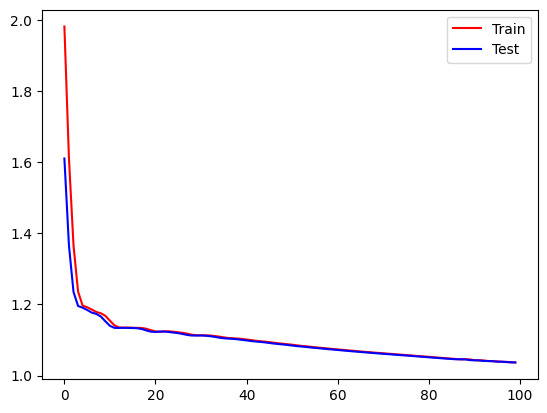

In [229]:
plt.plot(epoch_count, np.array(torch.tensor(train_loss).numpy()), label='Train', c='r')
plt.plot(epoch_count, np.array(torch.tensor(test_loss).numpy()), label='Test', c='b')
plt.legend()
plt.show()

In [242]:
predictions = model_pt(X_test_pt)

# creating a confusion matrix
cm = confusion_matrix(y_test_pt, np.array(torch.tensor(torch.argmax(predictions, axis=1)).numpy()))

score = f1_score(y_test_pt, np.array(torch.tensor(torch.argmax(predictions, axis=1)).numpy()), average = 'macro')
cm

C:\Users\pedro\AppData\Local\Temp\ipykernel_28748\2434148160.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  cm = confusion_matrix(y_test_pt, np.array(torch.tensor(torch.argmax(predictions, axis=1)).numpy()))
C:\Users\pedro\AppData\Local\Temp\ipykernel_28748\2434148160.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  score = f1_score(y_test_pt, np.array(torch.tensor(torch.argmax(predictions, axis=1)).numpy()), average = 'macro')


array([[ 1333,     0,  6131,  1949,     0,     0],
       [   42,     0,  2885,  1355,     0,     0],
       [  780,     0, 35444,  8283,     0,     0],
       [  455,     0, 17008, 12736,     0,     0],
       [    0,     0,   231,   168,     0,     0],
       [    1,     0,    32,    11,     0,     0]], dtype=int64)

In [243]:
score

0.22577308675483887

In [254]:
submit_predictions_nn = np.array(torch.tensor(torch.argmax(model_pt(X_final_test), axis=1)).numpy())

submission_df_nn = pd.DataFrame(submit_predictions_nn, columns=['change_type'])
submission_df_nn.insert(0, 'Id', submission_df['Id'])
submission_df_nn

C:\Users\pedro\AppData\Local\Temp\ipykernel_28748\184501322.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  submit_predictions_nn = np.array(torch.tensor(torch.argmax(model_pt(X_final_test), axis=1)).numpy())


,Id,change_type
0,0,2
1,1,2
2,2,2
3,3,2
4,4,2
...,...,...
120521,120521,3
120522,120522,3
120523,120523,2
120524,120524,2


In [255]:
from pathlib import Path  
filepath = Path('./submission_nn.csv')  
filepath.parent.mkdir(parents=True, exist_ok=True)  
submission_df_nn.to_csv(filepath, columns=['Id', 'change_type'], index=False) 